# 音声帯域で動かす DMT/OFDM デモ

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shima-nct/Communications_Engineering/blob/main/OFDM_Audio/audio_band_dmt_ofdm.ipynb)

ADSLで使われる **DMT (Discrete Multi-Tone)** と同じ基本原理を、48 kHz標本化の音声帯域へ縮小して確認します。各サブキャリアにはQPSKまたは16QAMを割り当て、IFFTでまとめて時間波形へ変換します。

このノートブックで確認する項目:

1. QPSK／16QAMによるビット列の複素シンボル化
2. エルミート対称配置による実数OFDM波形の生成
3. サイクリックプレフィックス (CP) の付加
4. 音声帯域のマルチパス伝送路とAWGN
5. トレーニングシンボルによる伝送路推定・1タップ等化
6. コンスタレーションとBERの確認

> **注意:** 実際のADSL規格準拠波形ではありません。ADSLは音声通話より広い銅線帯域を使い、規格固有のサブキャリア間隔、ビットローディング、同期、誤り訂正などを備えます。ここではDMT/OFDMの原理を音として再生できる帯域へ置き換えています。

## 1. ライブラリとパラメータ

Google Colabに標準で入っている NumPy、Matplotlib、IPython だけを使います。グラフの文字化けを避けるため、図中ラベルは英語にしています。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

rng = np.random.default_rng(20260721)

fs = 48_000                 # Audio sampling rate [Hz]
n_fft = 256                 # IFFT/FFT size
cp_len = 32                 # Cyclic prefix length [samples]
carrier_bins = np.arange(8, 85)  # 1.5 kHz ... 15.75 kHz
n_carriers = len(carrier_bins)
modulation = '16QAM'        # 'QPSK' または '16QAM'
bits_per_symbol = {'QPSK': 2, '16QAM': 4}[modulation]
n_payload_symbols = 332      # training symbolを含めて約2秒
snr_db = 24.0

subcarrier_spacing = fs / n_fft
symbol_duration = n_fft / fs
cp_duration = cp_len / fs

print(f'Modulation         : {modulation} ({bits_per_symbol} bits/carrier)')
print(f'Subcarrier spacing : {subcarrier_spacing:.1f} Hz')
print(f'Useful symbol time : {1e3 * symbol_duration:.3f} ms')
print(f'CP time            : {1e3 * cp_duration:.3f} ms')
print(f'Occupied band      : {carrier_bins[0]*subcarrier_spacing:.1f} to {carrier_bins[-1]*subcarrier_spacing:.1f} Hz')
print(f'Payload bits       : {n_payload_symbols*n_carriers*bits_per_symbol:,}')

Modulation         : 16QAM (4 bits/carrier)
Subcarrier spacing : 187.5 Hz
Useful symbol time : 5.333 ms
CP time            : 0.667 ms
Occupied band      : 1500.0 to 15750.0 Hz
Payload bits       : 102,256


## 2. Gray符号QPSK／16QAM

先ほどの `modulation` を `'QPSK'` または `'16QAM'` に変更するだけで方式を切り替えられます。QPSKは2 bit、16QAMは4 bitを1個の複素シンボルへ変換します。どちらも平均シンボル電力が1になるように正規化します。

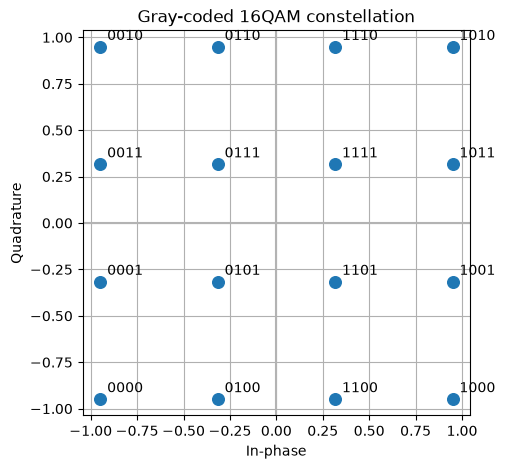

In [2]:
LEVELS = np.array([-3, -1, 1, 3])
LABELS = np.array([[0, 0], [0, 1], [1, 1], [1, 0]], dtype=np.uint8)
PAIR_TO_LEVEL = np.array([-3, -1, 3, 1])  # indices: 00, 01, 10, 11

def qpsk_mod(bits):
    bits = np.asarray(bits, dtype=np.uint8).reshape(-1, 2).astype(float)
    return ((1 - 2*bits[:, 0]) + 1j*(1 - 2*bits[:, 1])) / np.sqrt(2)

def qpsk_demod(symbols):
    symbols = np.asarray(symbols).reshape(-1)
    return np.column_stack((symbols.real < 0, symbols.imag < 0)).astype(np.uint8).reshape(-1)

def qam16_mod(bits):
    bits = np.asarray(bits, dtype=np.uint8).reshape(-1, 4)
    i_index = 2 * bits[:, 0] + bits[:, 1]
    q_index = 2 * bits[:, 2] + bits[:, 3]
    return (PAIR_TO_LEVEL[i_index] + 1j * PAIR_TO_LEVEL[q_index]) / np.sqrt(10)

def qam16_demod(symbols):
    symbols = np.asarray(symbols).reshape(-1) * np.sqrt(10)
    i_nearest = np.argmin(abs(symbols.real[:, None] - LEVELS[None, :]), axis=1)
    q_nearest = np.argmin(abs(symbols.imag[:, None] - LEVELS[None, :]), axis=1)
    return np.column_stack((LABELS[i_nearest], LABELS[q_nearest])).reshape(-1)

def modulate(bits):
    return qpsk_mod(bits) if modulation == 'QPSK' else qam16_mod(bits)

def demodulate(symbols):
    return qpsk_demod(symbols) if modulation == 'QPSK' else qam16_demod(symbols)

all_bits = np.array([[int(c) for c in f'{i:0{bits_per_symbol}b}']
                     for i in range(2**bits_per_symbol)], dtype=np.uint8)
constellation = modulate(all_bits)
plt.figure(figsize=(5, 5))
plt.scatter(constellation.real, constellation.imag, s=70)
for b, z in zip(all_bits, constellation):
    plt.annotate(''.join(map(str, b)), (z.real, z.imag), xytext=(5, 5), textcoords='offset points')
plt.axhline(0, color='0.7'); plt.axvline(0, color='0.7')
plt.xlabel('In-phase'); plt.ylabel('Quadrature')
plt.title(f'Gray-coded {modulation} constellation')
plt.grid(True); plt.axis('equal'); plt.show()

## 3. 送信機：サブキャリア配置、IFFT、CP付加

音声デバイスへ渡せる実数波形にするため、正の周波数ビン $X[k]$ に対して負の周波数側へ $X^*[k]$ を配置します。これを**エルミート対称**といいます。最初の1シンボルは受信側が既知のトレーニングシンボル、残りをデータとします。

### CP（Cyclic Prefix：サイクリックプレフィックス）とは

CPは、**OFDMシンボル末尾の一部をコピーして先頭へ付けたもの**です。たとえば末尾2標本をCPにすると、次のようになります。

```text
元のOFDMシンボル: [ A B C D E F G H ]
CP付加後:         [ G H | A B C D E F G H ]
                    CP    FFTで使う区間
```

建物内の反射や回線の周波数特性により、送信信号は複数の経路を通って時間差で到着します。遅延波がCP区間内に収まれば、受信側は影響を受けたCPを捨ててからFFTできるため、隣接するOFDMシンボル間の干渉を抑えられます。また、線形畳み込みをFFTで扱いやすい巡回畳み込みとして見なせるので、各サブキャリアを1個の複素数で割る**1タップ等化**が可能になります。

CP長は伝送路の最大遅延より長くする必要があります。このデモではCP長が32標本（0.667 ms）、最大反射遅延が13標本（0.271 ms）なので、遅延波はCP内に収まります。一方、CPは新しい情報を運ばないため、長くするほど伝送効率が低下します。今回の有効シンボル長は256標本なので、効率は $256/(256+32)=88.9\%$ です。

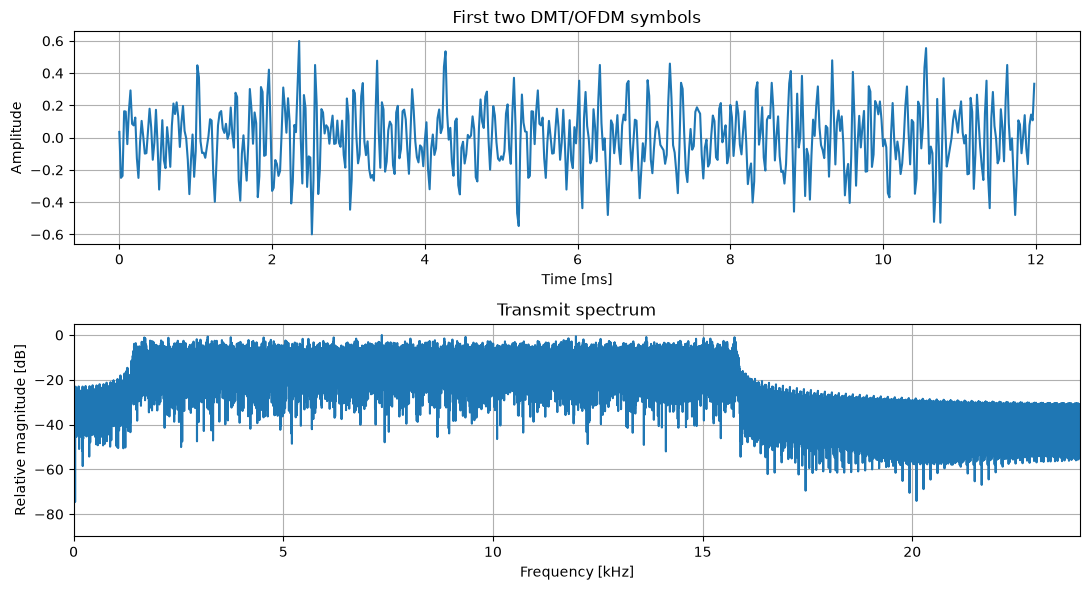

Waveform duration: 1.998 s
PAPR             : 13.17 dB


In [3]:
def dmt_modulate(carrier_symbols, n_fft, cp_len, carrier_bins):
    spectra = np.zeros((len(carrier_symbols), n_fft), dtype=complex)
    spectra[:, carrier_bins] = carrier_symbols
    spectra[:, -carrier_bins] = np.conj(carrier_symbols)
    useful = np.fft.ifft(spectra, axis=1).real * np.sqrt(n_fft)
    with_cp = np.concatenate((useful[:, -cp_len:], useful), axis=1)
    return with_cp.reshape(-1), spectra

training_bits = rng.integers(0, 2, n_carriers * bits_per_symbol, dtype=np.uint8)
training_symbols = modulate(training_bits)
payload_bits = rng.integers(0, 2, n_payload_symbols*n_carriers*bits_per_symbol, dtype=np.uint8)
payload_symbols = modulate(payload_bits).reshape(n_payload_symbols, n_carriers)
carrier_symbols = np.vstack((training_symbols, payload_symbols))

tx, tx_spectra = dmt_modulate(carrier_symbols, n_fft, cp_len, carrier_bins)
tx /= 1.05 * np.max(np.abs(tx))  # avoid clipping during audio playback
time = np.arange(len(tx)) / fs
papr_db = 10*np.log10(np.max(tx**2) / np.mean(tx**2))

fig, ax = plt.subplots(2, 1, figsize=(11, 6))
show_n = 2 * (n_fft + cp_len)
ax[0].plot(1e3*time[:show_n], tx[:show_n])
ax[0].set(xlabel='Time [ms]', ylabel='Amplitude', title='First two DMT/OFDM symbols')
ax[0].grid(True)

window = np.hanning(len(tx))
freq = np.fft.rfftfreq(len(tx), 1/fs)
psd = 20*np.log10(np.abs(np.fft.rfft(tx*window)) + 1e-12)
psd -= psd.max()
ax[1].plot(freq/1000, psd)
ax[1].set(xlim=(0, fs/2000), ylim=(-90, 5), xlabel='Frequency [kHz]',
          ylabel='Relative magnitude [dB]', title='Transmit spectrum')
ax[1].grid(True)
plt.tight_layout(); plt.show()
print(f'Waveform duration: {len(tx)/fs:.3f} s')
print(f'PAPR             : {papr_db:.2f} dB')

### ピーク対平均電力比

ピーク対平均電力比（peak-to-average power ratio; PAPR）は、信号の最大瞬時電力と平均電力の比です。離散時間信号 $x[n]$ に対して、

$$\mathrm{PAPR}=\frac{\max_n |x[n]|^2}{\mathrm{E}[|x[n]|^2]}, \qquad \mathrm{PAPR}_{\mathrm{dB}}=10\log_{10}(\mathrm{PAPR})$$

と定義します。OFDMでは、多数のサブキャリアの位相がそろった時刻に大きなピークが生じるため、PAPRが大きくなります。PAPRが13 dBなら、ピーク電力は平均電力の約20倍です。増幅器やDACではピークを収容するためのバックオフが必要であり、不足するとクリッピングによる非線形ひずみ、帯域外放射、BER増加が生じます。

### 送信波形を音として聞く

再生時は音量を小さめにしてください。短いノイズ状の音が聞こえます。

In [4]:
display(Audio(tx, rate=fs, normalize=False))

## 4. 音声帯域の伝送路

直接波に加えて、5標本後と13標本後に反射波が届くFIR伝送路を作ります。最大遅延13標本はCP長32標本より短いため、FFT区間内のシンボル間干渉を防げます。最後にAWGNを加えます。

### 加法性白色ガウス雑音

受信信号には、加法性白色ガウス雑音（additive white Gaussian noise; AWGN）を加えます。AWGNを $n(t)$ とすると、受信信号は $y(t)=x(t)+n(t)$ で表されます。$n(t)$ はガウス分布に従い、解析帯域内で一定の電力スペクトル密度を持つものとします。

設定したSNRから雑音電力を求め、正規乱数を信号へ加えます。

```python
signal_power = np.mean(rx_clean**2)
noise_power = signal_power / 10**(snr_db/10)
rx = rx_clean + rng.normal(scale=np.sqrt(noise_power), size=len(rx_clean))
```

信号電力 $P_{\mathrm{signal}}$ と雑音電力 $P_{\mathrm{noise}}$ の比を

$$\mathrm{SNR}_{\mathrm{dB}}=10\log_{10}\left(\frac{P_{\mathrm{signal}}}{P_{\mathrm{noise}}}\right)$$

とします。実際の音響通信に含まれる背景音、帯域制限、非線形ひずみなどは、このモデルでは扱いません。

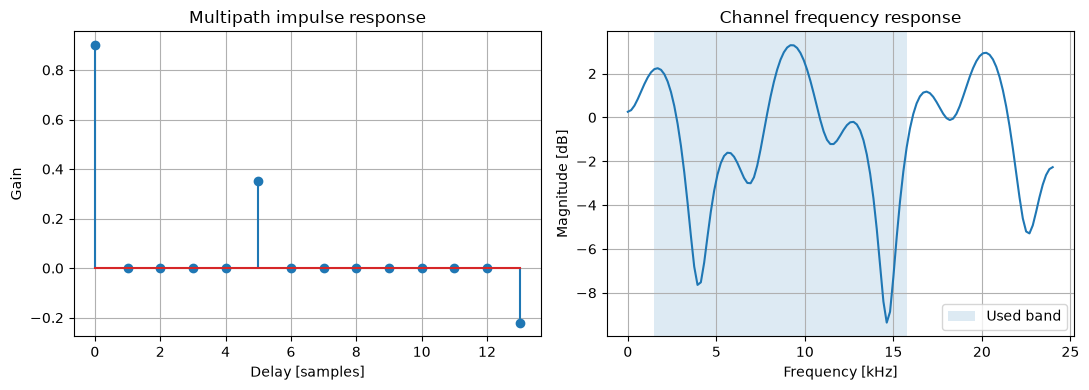

SNR: 24.0 dB


In [5]:
channel_h = np.zeros(14)
channel_h[[0, 5, 13]] = [0.90, 0.35, -0.22]
rx_clean = np.convolve(tx, channel_h)[:len(tx)]
signal_power = np.mean(rx_clean**2)
noise_power = signal_power / 10**(snr_db/10)
rx = rx_clean + rng.normal(scale=np.sqrt(noise_power), size=len(rx_clean))

channel_response = np.fft.rfft(channel_h, n_fft)
channel_freq = np.fft.rfftfreq(n_fft, 1/fs)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].stem(np.arange(len(channel_h)), channel_h)
ax[0].set(xlabel='Delay [samples]', ylabel='Gain', title='Multipath impulse response')
ax[0].grid(True)
ax[1].plot(channel_freq/1000, 20*np.log10(abs(channel_response)+1e-12))
ax[1].axvspan(carrier_bins[0]*subcarrier_spacing/1000,
              carrier_bins[-1]*subcarrier_spacing/1000, alpha=0.15, label='Used band')
ax[1].set(xlabel='Frequency [kHz]', ylabel='Magnitude [dB]', title='Channel frequency response')
ax[1].grid(True); ax[1].legend()
plt.tight_layout(); plt.show()
print(f'SNR: {snr_db:.1f} dB')

## 5. 受信機：CP除去、FFT、伝送路推定、等化

受信開始位置は分かっているものとします。トレーニングシンボルについて、各サブキャリアの受信値を既知の送信値で割り、複素伝達関数を推定します。各データシンボルを推定値で割る処理が1タップ等化です。

### 伝送路推定と等化

**等化（equalization）**とは、伝送路によって生じた振幅の増減と位相の回転を受信側で補正し、送信時のシンボルへ戻す処理です。伝送路の影響を調べる処理が**伝送路推定**、その推定結果を使って影響を取り除く処理が**等化**です。

サブキャリア $k$ の送信シンボルを $X[k]$、伝送路の複素利得を $H[k]$、雑音を $N[k]$ とすると、受信シンボルは

$$Y[k] = H[k]X[k] + N[k]$$

と表せます。最初に受信側も値を知っているトレーニングシンボル $X_{\mathrm{train}}[k]$ を送り、

$$\hat{H}[k] = \frac{Y_{\mathrm{train}}[k]}{X_{\mathrm{train}}[k]}$$

として、各サブキャリアの伝送路を推定します。その後、データシンボルを

$$\hat{X}[k] = \frac{Y[k]}{\hat{H}[k]}$$

と補正します。$\hat{H}[k] \approx H[k]$ で雑音が小さければ、$\hat{X}[k] \approx X[k]$ となります。OFDMではCPによって、各サブキャリアの伝送路をほぼ1個の複素数として扱えるため、この割り算1回だけの**1タップ等化**ができます。

```text
送信 X[k] → 伝送路 H[k] → 受信 Y[k] → 推定した H[k] で割る → X[k] に近づく
```

次の図では、等化前に回転・拡大縮小していた点群が、等化後には設定した変調方式の理想点付近へ戻る様子を確認できます。なお、このデモは単純なゼロフォーシング等化です。$|H[k]|$ が非常に小さいサブキャリアでは、割り算によって雑音も増幅されるため、実用システムではMMSE等化や、そのサブキャリアへ割り当てるビット数を減らす方法なども使われます。

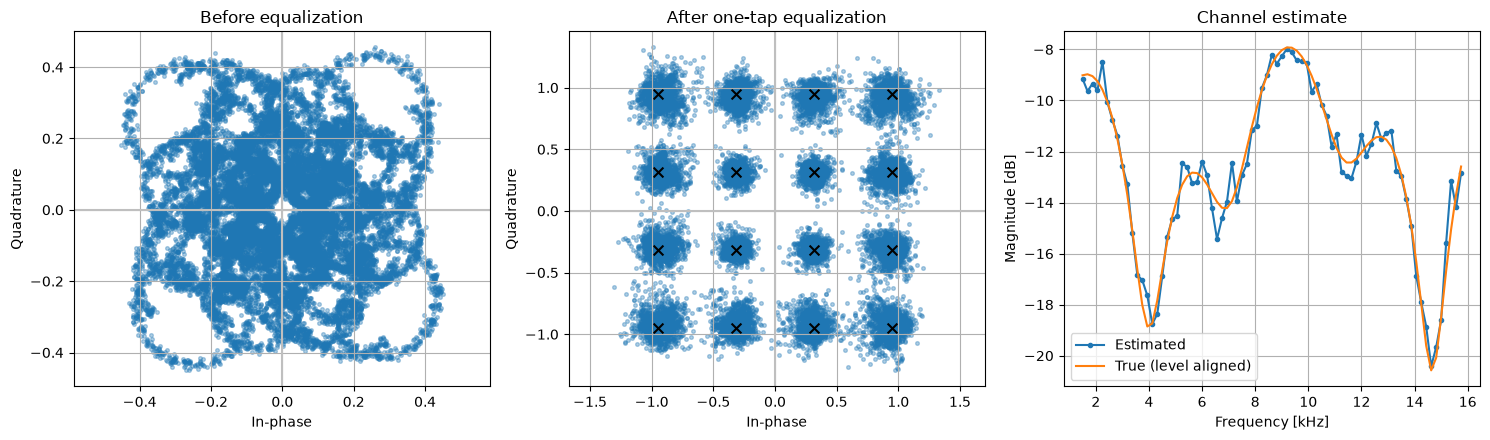

Bit errors : 88 / 102256
BER        : 8.606e-04


In [6]:
block_len = n_fft + cp_len
n_symbols = 1 + n_payload_symbols
rx_blocks = rx[:n_symbols*block_len].reshape(n_symbols, block_len)
rx_useful = rx_blocks[:, cp_len:]
received_spectra = np.fft.fft(rx_useful, axis=1) / np.sqrt(n_fft)
received_carriers = received_spectra[:, carrier_bins]

h_est = received_carriers[0] / training_symbols
equalized = received_carriers[1:] / h_est
rx_bits = demodulate(equalized)
bit_errors = np.count_nonzero(rx_bits != payload_bits)
ber = bit_errors / len(payload_bits)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
before = received_carriers[1:].reshape(-1)
after = equalized.reshape(-1)
ax[0].scatter(before.real, before.imag, s=7, alpha=0.35)
ax[0].set_title('Before equalization')
ax[1].scatter(after.real, after.imag, s=7, alpha=0.35)
ax[1].scatter(constellation.real, constellation.imag, marker='x', color='black', s=50)
ax[1].set_title('After one-tap equalization')
used_freq = carrier_bins * subcarrier_spacing
ax[2].plot(used_freq/1000, 20*np.log10(abs(h_est)+1e-12), 'o-', ms=3, label='Estimated')
true_h = np.fft.fft(channel_h, n_fft)[carrier_bins]
offset_db = np.mean(20*np.log10(abs(h_est)+1e-12) - 20*np.log10(abs(true_h)+1e-12))
ax[2].plot(used_freq/1000, 20*np.log10(abs(true_h)+1e-12)+offset_db, label='True (level aligned)')
ax[2].set(xlabel='Frequency [kHz]', ylabel='Magnitude [dB]', title='Channel estimate')
ax[2].legend(); ax[2].grid(True)
for a in ax[:2]:
    a.axhline(0, color='0.75'); a.axvline(0, color='0.75')
    a.set_xlabel('In-phase'); a.set_ylabel('Quadrature')
    a.grid(True); a.axis('equal')
plt.tight_layout(); plt.show()
print(f'Bit errors : {bit_errors} / {len(payload_bits)}')
print(f'BER        : {ber:.3e}')

### BER（Bit Error Rate：ビット誤り率）とは

BERは、送信した全ビットのうち、受信側で誤って判定されたビットの割合です。

$$\mathrm{BER}=\frac{\text{誤ったビット数}}{\text{送信した全ビット数}}$$

たとえば6160 bitを送り、そのうち21 bitを誤った場合は、

$$\mathrm{BER}=\frac{21}{6160}\approx3.41\times10^{-3}$$

となり、およそ1000 bit当たり3.4 bitを誤ったことを表します。BERは小さいほど良く、SNRを高くすると一般に小さくなります。同じ平均シンボル電力と受信SNRでは、理想点の間隔が広いQPSKの方が16QAMより誤りにくい一方、1シンボルで運べるビット数は半分です。

コードでは、送信ビット列 `payload_bits` と復調後の `rx_bits` を位置ごとに比較しています。

```python
bit_errors = np.count_nonzero(rx_bits != payload_bits)
ber = bit_errors / len(payload_bits)
```

なお、有限個のビットによるシミュレーションで `BER = 0` になっても、誤り確率が厳密にゼロという意味ではありません。より信頼できるBERを求めるには、送信ビット数を増やし、複数の雑音系列で繰り返して評価します。

## 6. まとめ

- QPSKまたは16QAMのシンボルを多数の直交サブキャリアへ並べ、IFFTするとDMT/OFDM波形になる。
- エルミート対称に配置すると、IFFT出力は音声機器で扱える実数信号になる。
- CPが伝送路の最大遅延より長ければ、各サブキャリアを独立な複素利得として扱いやすい。
- トレーニングシンボルから各サブキャリアの利得と位相を推定し、1タップで等化できる。
- OFDMは多数のサブキャリアが重なるため、時間波形のPAPRが大きくなりやすい。

### 課題例

1. `snr_db` を 30, 20, 15, 10 dB と変え、BERとコンスタレーションを比較しなさい。
2. `cp_len` を 8 に変更し、遅延13標本の反射波があると結果がどう変わるか説明しなさい。
3. 使用するサブキャリア範囲を変更し、音とスペクトルの変化を確認しなさい。
4. `equalized = received_carriers[1:]` として等化を無効にし、等化前後のBERを比較しなさい。
5. `modulation` を `'QPSK'` と `'16QAM'` に切り替え、1シンボル当たりのビット数、BER、コンスタレーションを比較しなさい。

### この簡易モデルで省略したもの

実用システムに必要なフレーム同期、標本化周波数ずれ、搬送波周波数ずれ、パイロット追従、サブキャリアごとのビットローディング、誤り訂正、インターリーブ、DAC/ADCやスピーカー・マイクの非線形性は省略しています。